RESUME ROLE CLASSIFICATION

In [2]:
import os
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLP libraries
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from collections import Counter

# Scikit-learn libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier


In [3]:
df=pd.read_csv("data/resume.csv")
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [4]:
df.shape

(2484, 4)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   ID           2484 non-null   int64
 1   Resume_str   2484 non-null   str  
 2   Resume_html  2484 non-null   str  
 3   Category     2484 non-null   str  
dtypes: int64(1), str(3)
memory usage: 52.3 MB


In [6]:
df.isnull().sum()

ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

EDA

In [7]:
X = df["Resume_str"]
y = df["Category"]

print("features",X.head())
print("Target",y.head())

features 0             HR ADMINISTRATOR/MARKETING ASSOCIATE\...
1             HR SPECIALIST, US HR OPERATIONS      ...
2             HR DIRECTOR       Summary      Over 2...
3             HR SPECIALIST       Summary    Dedica...
4             HR MANAGER         Skill Highlights  ...
Name: Resume_str, dtype: str
Target 0    HR
1    HR
2    HR
3    HR
4    HR
Name: Category, dtype: str


In [8]:
print(df["Category"].unique())

<ArrowStringArray>
[                    'HR',               'DESIGNER', 'INFORMATION-TECHNOLOGY',
                'TEACHER',               'ADVOCATE',   'BUSINESS-DEVELOPMENT',
             'HEALTHCARE',                'FITNESS',            'AGRICULTURE',
                    'BPO',                  'SALES',             'CONSULTANT',
          'DIGITAL-MEDIA',             'AUTOMOBILE',                   'CHEF',
                'FINANCE',                'APPAREL',            'ENGINEERING',
             'ACCOUNTANT',           'CONSTRUCTION',       'PUBLIC-RELATIONS',
                'BANKING',                   'ARTS',               'AVIATION']
Length: 24, dtype: str


so multi class classification

In [9]:
df["Category"].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

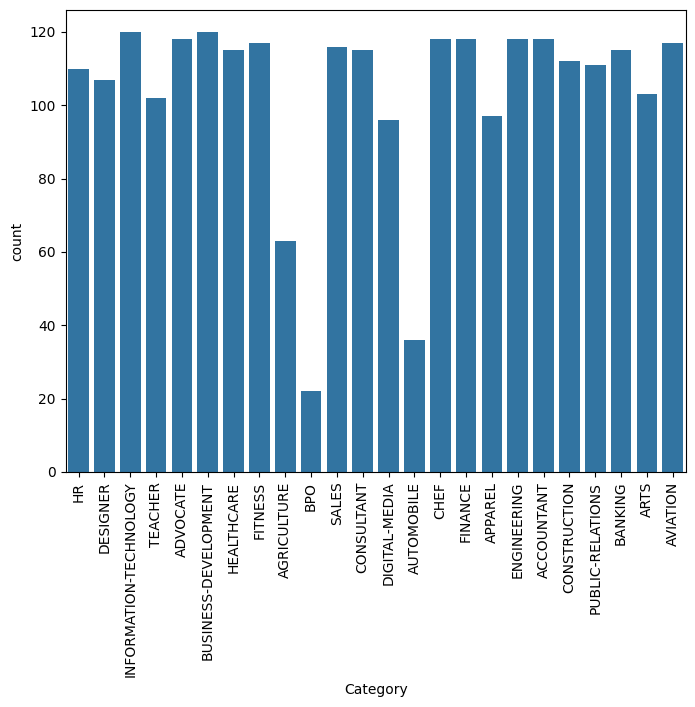

In [10]:
plt.figure(figsize=(8,6))
sns.countplot(x=df["Category"])
plt.xticks(rotation=90)
plt.show()

minor class imbalance,

PREPROCESSING

In [11]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [12]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

In [13]:
def clean_resume(text):
    text = str(text).lower()

    # remove urls
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"www\S+", " ", text)

    # remove emails
    text = re.sub(r"\S+@\S+", " ", text)

    # remove phone numbers
    text = re.sub(r"\d{10,}", " ", text)

    # keep only letters and spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # tokenize
    words = word_tokenize(text)

    # remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(words)

In [14]:
X_cleaned = X.apply(clean_resume)
X_cleaned.head()

0    administrator marketing associate administrato...
1    specialist operation summary versatile medium ...
2    director summary year experience recruiting pl...
3    specialist summary dedicated driven dynamic ye...
4    manager skill highlight skill department start...
Name: Resume_str, dtype: str

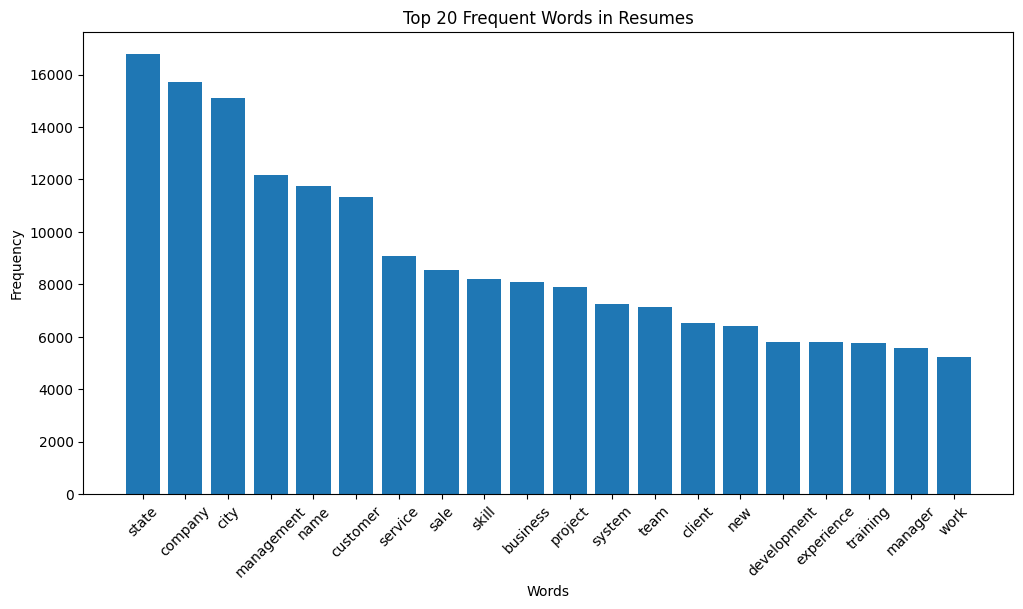

In [15]:
# Combine all cleaned resumes
all_words = " ".join(X_cleaned).split()

# Count word frequency
word_counts = Counter(all_words)

# Get top 20 words
top_words = word_counts.most_common(20)

# Separate words and counts
words = [word for word, count in top_words]
counts = [count for word, count in top_words]

# Plot
plt.figure(figsize=(12,6))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 20 Frequent Words in Resumes")
plt.show()

cleaning worked
noise removed
text looks meaningful 

TRAIN TEST SPLIT

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1987,)
(497,)
(1987,)
(497,)


In [17]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

In [18]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [19]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(1987, 5000)
(497, 5000)


creating baseline model

In [20]:
# Logistic Regression Model

logistic_model = LogisticRegression()

logistic_model.fit(X_train_tfidf, y_train)

y_pred_logistic = logistic_model.predict(X_test_tfidf)

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", accuracy_logistic)
print(classification_report(y_test, y_pred_logistic, zero_division=0))

Logistic Regression Accuracy: 0.6579476861167002
                        precision    recall  f1-score   support

            ACCOUNTANT       0.83      0.86      0.85        29
              ADVOCATE       0.48      0.53      0.51        30
           AGRICULTURE       1.00      0.12      0.22         8
               APPAREL       0.50      0.40      0.44        20
                  ARTS       0.25      0.22      0.24        18
            AUTOMOBILE       1.00      0.17      0.29         6
              AVIATION       0.75      0.86      0.80        21
               BANKING       0.73      0.70      0.71        23
                   BPO       0.00      0.00      0.00         2
  BUSINESS-DEVELOPMENT       0.95      0.74      0.83        27
                  CHEF       0.85      0.71      0.77        24
          CONSTRUCTION       0.89      0.74      0.81        34
            CONSULTANT       0.43      0.30      0.35        20
              DESIGNER       0.75      0.79      0.77 

i understood the model with baseline model ,now trying with other models and ensemble it

In [21]:
# Naive Bayes Model

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)
print(classification_report(y_test, y_pred_nb, zero_division=0))

Naive Bayes Accuracy: 0.5674044265593562
                        precision    recall  f1-score   support

            ACCOUNTANT       0.77      0.93      0.84        29
              ADVOCATE       0.55      0.40      0.46        30
           AGRICULTURE       1.00      0.12      0.22         8
               APPAREL       0.75      0.30      0.43        20
                  ARTS       0.50      0.06      0.10        18
            AUTOMOBILE       0.00      0.00      0.00         6
              AVIATION       0.58      0.71      0.64        21
               BANKING       0.71      0.52      0.60        23
                   BPO       0.00      0.00      0.00         2
  BUSINESS-DEVELOPMENT       0.58      0.67      0.62        27
                  CHEF       0.85      0.71      0.77        24
          CONSTRUCTION       0.88      0.62      0.72        34
            CONSULTANT       0.67      0.10      0.17        20
              DESIGNER       0.82      0.74      0.78        1

In [22]:
# Random Forest Model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_tfidf, y_train)

y_pred_rf = rf_model.predict(X_test_tfidf)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)
print(classification_report(y_test, y_pred_rf, zero_division=0))

Random Forest Accuracy: 0.7424547283702213
                        precision    recall  f1-score   support

            ACCOUNTANT       0.82      0.97      0.89        29
              ADVOCATE       0.93      0.87      0.90        30
           AGRICULTURE       0.60      0.38      0.46         8
               APPAREL       0.69      0.55      0.61        20
                  ARTS       0.33      0.11      0.17        18
            AUTOMOBILE       0.00      0.00      0.00         6
              AVIATION       0.78      0.86      0.82        21
               BANKING       0.70      0.61      0.65        23
                   BPO       0.00      0.00      0.00         2
  BUSINESS-DEVELOPMENT       0.85      0.81      0.83        27
                  CHEF       0.78      0.75      0.77        24
          CONSTRUCTION       0.93      0.82      0.88        34
            CONSULTANT       0.83      0.50      0.62        20
              DESIGNER       0.85      0.89      0.87       

In [23]:
# Support Vector Machine Model

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", accuracy_svm)
print(classification_report(y_test, y_pred_svm, zero_division=0))

SVM Accuracy: 0.7082494969818913
                        precision    recall  f1-score   support

            ACCOUNTANT       0.84      0.93      0.89        29
              ADVOCATE       0.62      0.70      0.66        30
           AGRICULTURE       0.40      0.25      0.31         8
               APPAREL       0.63      0.60      0.62        20
                  ARTS       0.50      0.22      0.31        18
            AUTOMOBILE       0.67      0.33      0.44         6
              AVIATION       0.75      0.86      0.80        21
               BANKING       0.76      0.70      0.73        23
                   BPO       0.33      0.50      0.40         2
  BUSINESS-DEVELOPMENT       0.91      0.74      0.82        27
                  CHEF       0.85      0.71      0.77        24
          CONSTRUCTION       0.88      0.82      0.85        34
            CONSULTANT       0.54      0.35      0.42        20
              DESIGNER       0.81      0.89      0.85        19
      

In [24]:
# AdaBoost Model

ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=1,
        random_state=42
    ),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

ada_model.fit(X_train_tfidf, y_train)

y_pred_ada = ada_model.predict(X_test_tfidf)

accuracy_ada = accuracy_score(y_test, y_pred_ada)

print("AdaBoost Accuracy:", accuracy_ada)
print(classification_report(y_test, y_pred_ada, zero_division=0))

AdaBoost Accuracy: 0.6096579476861167
                        precision    recall  f1-score   support

            ACCOUNTANT       0.87      0.93      0.90        29
              ADVOCATE       1.00      0.70      0.82        30
           AGRICULTURE       0.00      0.00      0.00         8
               APPAREL       0.88      0.35      0.50        20
                  ARTS       0.09      0.56      0.15        18
            AUTOMOBILE       0.00      0.00      0.00         6
              AVIATION       0.94      0.81      0.87        21
               BANKING       0.75      0.13      0.22        23
                   BPO       0.00      0.00      0.00         2
  BUSINESS-DEVELOPMENT       0.76      0.59      0.67        27
                  CHEF       0.94      0.71      0.81        24
          CONSTRUCTION       0.88      0.88      0.88        34
            CONSULTANT       0.80      0.60      0.69        20
              DESIGNER       0.73      0.84      0.78        19
 

In [25]:
# XGBoost Model

label_encoder = LabelEncoder()

y_train_xgb = label_encoder.fit_transform(y_train)
y_test_xgb = label_encoder.transform(y_test)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train_tfidf, y_train_xgb)

y_pred_xgb_encoded = xgb_model.predict(X_test_tfidf)

y_pred_xgb = label_encoder.inverse_transform(y_pred_xgb_encoded)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", accuracy_xgb)
print(classification_report(y_test, y_pred_xgb, zero_division=0))

XGBoost Accuracy: 0.7686116700201208
                        precision    recall  f1-score   support

            ACCOUNTANT       0.93      0.93      0.93        29
              ADVOCATE       0.93      0.87      0.90        30
           AGRICULTURE       0.62      0.62      0.62         8
               APPAREL       0.73      0.55      0.63        20
                  ARTS       0.56      0.56      0.56        18
            AUTOMOBILE       0.00      0.00      0.00         6
              AVIATION       0.75      0.86      0.80        21
               BANKING       0.67      0.52      0.59        23
                   BPO       1.00      0.50      0.67         2
  BUSINESS-DEVELOPMENT       0.78      0.78      0.78        27
                  CHEF       0.90      0.79      0.84        24
          CONSTRUCTION       0.85      0.97      0.90        34
            CONSULTANT       0.72      0.65      0.68        20
              DESIGNER       0.80      0.84      0.82        19
  

comparing 4 models

In [26]:
model_comparison = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "XGBoost",
        "AdaBoost"
    ],
    "Accuracy": [
        accuracy_nb,
        accuracy_logistic,
        accuracy_rf,
        accuracy_svm,
        accuracy_xgb,
        accuracy_ada
    ],
    "Weighted_F1": [
        f1_score(y_test, y_pred_nb, average="weighted"),
        f1_score(y_test, y_pred_logistic, average="weighted"),
        f1_score(y_test, y_pred_rf, average="weighted"),
        f1_score(y_test, y_pred_svm, average="weighted"),
        f1_score(y_test, y_pred_xgb, average="weighted"),
        f1_score(y_test, y_pred_ada, average="weighted")
    ]
})

model_comparison.sort_values(
    by=["Weighted_F1", "Accuracy"],
    ascending=False
)

,Model,Accuracy,Weighted_F1
4,XGBoost,0.768612,0.765157
2,Random Forest,0.742455,0.728817
3,SVM,0.708249,0.700924
1,Logistic Regression,0.657948,0.652150
5,AdaBoost,0.609658,0.620731
0,Naive Bayes,0.567404,0.545968


HYPER PARAMETER TUNING

In [27]:
# Hyperparameter Tuning for XGBoost

xgb_param_grid = {
    "n_estimators": [100],
    "max_depth": [5, 6],
    "learning_rate": [0.1]
}

xgb_grid_search = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="mlogloss",
        n_jobs=-1
    ),
    param_grid=xgb_param_grid,
    cv=2,
    scoring="f1_weighted",
    n_jobs=-1
)

xgb_grid_search.fit(X_train_tfidf, y_train_xgb)

print("Best Parameters:", xgb_grid_search.best_params_)
print("Best Cross Validation Score:", xgb_grid_search.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best Cross Validation Score: 0.7336679938608233


In [28]:
# Final Tuned XGBoost Evaluation

best_xgb = xgb_grid_search.best_estimator_

y_pred_best_xgb_encoded = best_xgb.predict(X_test_tfidf)

y_pred_best_xgb = label_encoder.inverse_transform(y_pred_best_xgb_encoded)

accuracy_best_xgb = accuracy_score(y_test, y_pred_best_xgb)

f1_best_xgb = f1_score(
    y_test,
    y_pred_best_xgb,
    average="weighted"
)

print("Tuned XGBoost Accuracy:", accuracy_best_xgb)
print("Tuned XGBoost Weighted F1:", f1_best_xgb)

print(classification_report(y_test, y_pred_best_xgb, zero_division=0))

Tuned XGBoost Accuracy: 0.7706237424547284
Tuned XGBoost Weighted F1: 0.7666079101446939
                        precision    recall  f1-score   support

            ACCOUNTANT       0.93      0.97      0.95        29
              ADVOCATE       0.93      0.90      0.92        30
           AGRICULTURE       0.57      0.50      0.53         8
               APPAREL       0.73      0.55      0.63        20
                  ARTS       0.50      0.50      0.50        18
            AUTOMOBILE       0.00      0.00      0.00         6
              AVIATION       0.75      0.86      0.80        21
               BANKING       0.67      0.52      0.59        23
                   BPO       1.00      0.50      0.67         2
  BUSINESS-DEVELOPMENT       0.81      0.81      0.81        27
                  CHEF       0.95      0.79      0.86        24
          CONSTRUCTION       0.85      0.97      0.90        34
            CONSULTANT       0.76      0.65      0.70        20
              

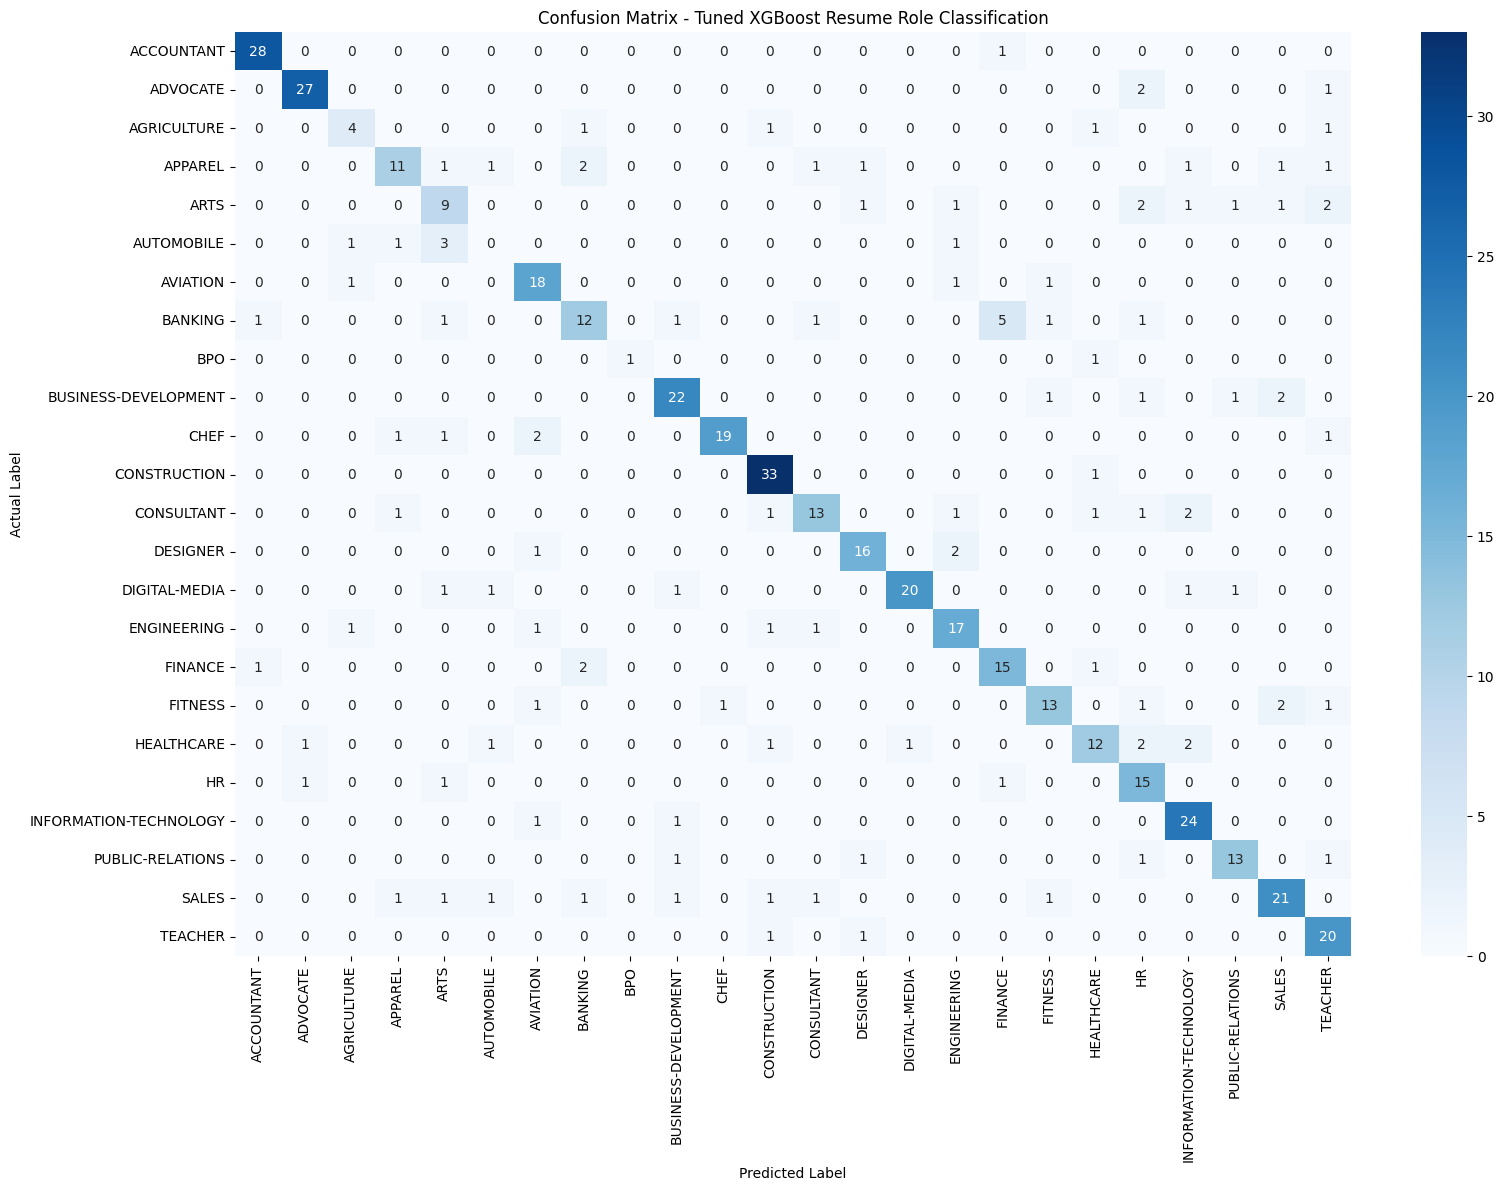

In [29]:
# Confusion Matrix for Tuned XGBoost

cm = confusion_matrix(
    y_test,
    y_pred_best_xgb
)

labels = label_encoder.classes_

plt.figure(figsize=(18, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Tuned XGBoost Resume Role Classification")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

In [30]:
# Save Final Model, Vectorizer, and Label Encoder

os.makedirs("models", exist_ok=True)

joblib.dump(best_xgb, "models/resume_classifier.pkl")
joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")
joblib.dump(label_encoder, "models/label_encoder.pkl")

print("Model, TF-IDF vectorizer, and label encoder saved successfully.")

Model, TF-IDF vectorizer, and label encoder saved successfully.


# FINAL PROJECT SUMMARY

Project: Resume Role Classification System
Problem Type: Multi-Class NLP Classification

Project Workflow:

1. Dataset collected from Kaggle resume dataset
2. Performed EDA to understand category distribution, class imbalance, and missing values
3. Applied NLP preprocessing including text cleaning, tokenization, stopword removal, and lemmatization
4. Converted resume text into numerical features using TF-IDF vectorization with n-grams
5. Trained and evaluated 6 classification models:
   Naive Bayes, Logistic Regression, SVM, Random Forest, AdaBoost, and XGBoost
6. Compared models using Accuracy and Weighted F1 Score
7. Applied hyperparameter tuning using GridSearchCV with cross-validation
8. Selected the best-performing model
9. Saved the final model, TF-IDF vectorizer, and label encoder using Joblib
10. Deployed the system using Streamlit with PDF resume upload and text extraction

Final Selected Model:
Tuned XGBoost

Final Performance:
Accuracy: 76.86%
Weighted F1 Score: 76.53%

Conclusion:
The Resume Role Classification System successfully predicts the most suitable job category from uploaded resume PDFs using NLP, TF-IDF, and machine learning.
